In [1]:
%load_ext autoreload
%autoreload 2

In [22]:
import sys
sys.path.append('..')
from compiler.LOGraph import *
from scripts.compare_trees import nx_to_vdsp
from scripts.random_graph_order import generate_graphs, get_spanning_tree
import numpy as np
import perceval.components as symb
import random 
random.seed(1234)

In [23]:
graph = nx.Graph([(0, 1), (1, 2), (0, 2),(2,3),(3,4),(4,1),(4,5),(2,5)])
mapping = [[1,0,2],[3,4,5]]
sts = get_spanning_trees(graph, mapping)
edge_orders = []
for st in sts:
    print(st.edges)
    tree = nx_to_vdsp(st,list(st.edges)[0][0])
    lograph, depth = build_optimal_tree(tree, tree.head, LOGraph2(mapping), False)
    print("depth",depth)
    pcvl.pdisplay(lograph.circuit)
#     edge_orders.append((edge_order,depth))
#     print(edge_order,depth)

# edge_orders = sorted(edge_orders,key = lambda k: k[1])
# print("sorted edge orders:",edge_orders,"start vertex",edge_orders[0][0][0][0])
# lograph = LOGraph2(mapping)
# for edge_order in edge_orders:
#     for i, edge in enumerate(edge_order[0]):
#         lograph.add_edge(edge)
# #         pcvl.pdisplay(lograph.circuit).save_png('16fusion_'+str(i)+'.svg')
# pcvl.pdisplay(lograph.circuit)
# max(loopify(lograph.circuit,display=False)[0])

[(3, 2), (2, 1), (2, 5), (1, 4)]
no children, return
add edge (1, 4)
sink 0 to 4 pos map: {1: 4, 0: 0, 2: 2, 3: 14, 4: 16, 5: 18}
sink 12 to 14 pos map: {1: 4, 0: 0, 2: 2, 3: 12, 4: 16, 5: 18}
fuse 4 6 (1, 4)
fuse 14 16 (1, 4)
no children, return
add edge (2, 5)
sink 12 to 16 pos map: {1: 0, 0: 2, 2: 4, 3: 12, 4: 14, 5: 18}
fuse 4 6 (2, 5)
fuse 16 18 (2, 5)
add edge (2, 1)
other vertex mapping: {1: 0, 0: 2, 2: 4, 3: 14, 4: 16, 5: 18} self vertex_pos_map {1: 0, 0: 2, 2: 8, 3: 12, 4: 14, 5: 10}
mode map {0: 0, 1: 1, 2: 2, 3: 3, 4: 8, 5: 9, 14: 12, 15: 13, 16: 14, 17: 15, 18: 10, 19: 11, 6: 20, 7: 21, 8: 22, 9: 23, 10: 24, 11: 25, 12: 26, 13: 27}
other operation map [((1, 4), 0, 6), ((1, 4), 12, 16)]
sink 0 to 18 pos map: {1: 18, 0: 0, 2: 6, 3: 10, 4: 12, 5: 8}
fuse 18 20 (1, 4)
sink 12 to 24 pos map: {1: 16, 0: 0, 2: 6, 3: 10, 4: 24, 5: 8}
fuse 24 26 (1, 4)
sink 16 to 32 pos map: {1: 32, 0: 0, 2: 6, 3: 10, 4: 22, 5: 8}
sink 6 to 24 pos map: {1: 32, 0: 0, 2: 24, 3: 8, 4: 20, 5: 6}
fuse 24

In [24]:
lograph.initial_vertex_mapping

{}

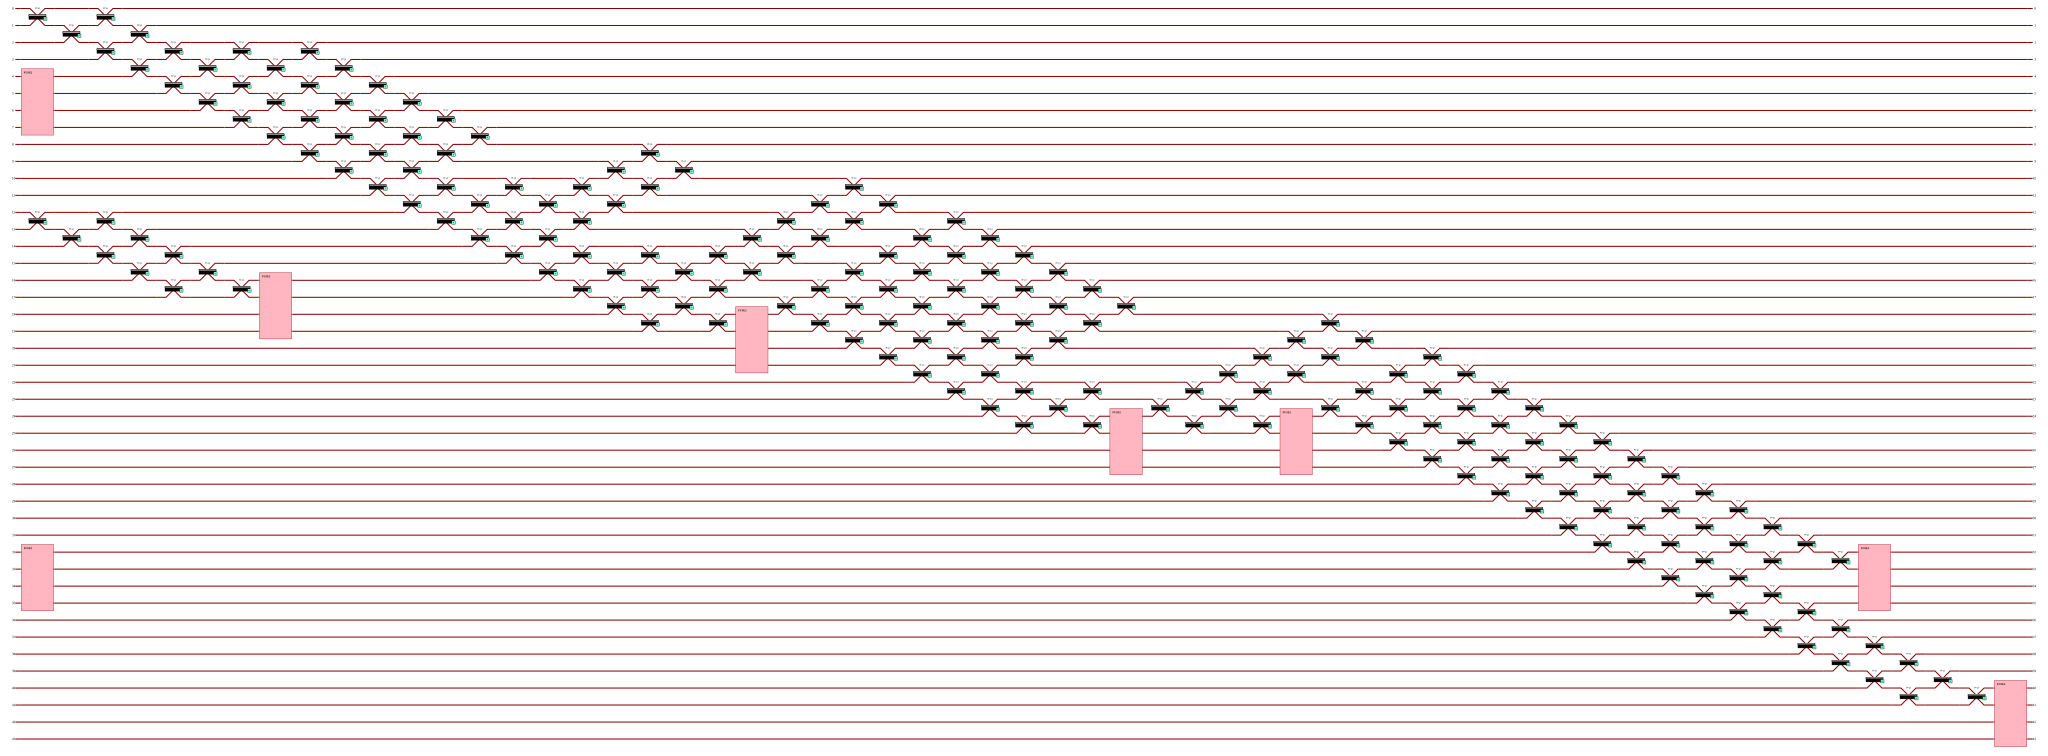

In [25]:
pcvl.pdisplay(lograph.circuit)

In [4]:
pcvl.pdisplay(lograph.circuit).save_png('4edge_example_mergecheck_min_dfs.svg')

In [40]:
lograph.get_fusion_gates_depth()

{((4, 5, 6, 7),
  <perceval.components.linear_circuit.Circuit at 0x7921aa52ead0>): 0,
 ((14, 15, 16, 17),
  <perceval.components.linear_circuit.Circuit at 0x7921ac4aa9d0>): 2,
 ((18, 19, 20, 21),
  <perceval.components.linear_circuit.Circuit at 0x79219dd61310>): 4,
 ((28, 29, 30, 31),
  <perceval.components.linear_circuit.Circuit at 0x7921ac9c2c90>): 2,
 ((32, 33, 34, 35),
  <perceval.components.linear_circuit.Circuit at 0x7921a3d4e7d0>): 4,
 ((42, 43, 44, 45),
  <perceval.components.linear_circuit.Circuit at 0x7921ac61d150>): 2,
 ((46, 47, 48, 49),
  <perceval.components.linear_circuit.Circuit at 0x7921a820cb90>): 4,
 ((56, 57, 58, 59),
  <perceval.components.linear_circuit.Circuit at 0x7921a3d4d5d0>): 2,
 ((58, 59, 60, 61),
  <perceval.components.linear_circuit.Circuit at 0x792162250350>): 6,
 ((66, 67, 68, 69),
  <perceval.components.linear_circuit.Circuit at 0x7921a3853a90>): 4,
 ((66, 67, 68, 69),
  <perceval.components.linear_circuit.Circuit at 0x7921a36d1590>): 8,
 ((74, 75, 76,

In [41]:
lograph.fusion_map

{(0,
  8): [((4, 5, 6, 7),
   <perceval.components.linear_circuit.Circuit at 0x7921aa52ead0>), ((14,
    15,
    16,
    17),
   <perceval.components.linear_circuit.Circuit at 0x7921ac4aa9d0>)],
 (8,
  15): [((18, 19, 20, 21),
   <perceval.components.linear_circuit.Circuit at 0x79219dd61310>), ((28,
    29,
    30,
    31),
   <perceval.components.linear_circuit.Circuit at 0x7921ac9c2c90>)],
 (4,
  8): [((32, 33, 34, 35),
   <perceval.components.linear_circuit.Circuit at 0x7921a3d4e7d0>), ((42,
    43,
    44,
    45),
   <perceval.components.linear_circuit.Circuit at 0x7921ac61d150>)],
 (2,
  4): [((46, 47, 48, 49),
   <perceval.components.linear_circuit.Circuit at 0x7921a820cb90>), ((56,
    57,
    58,
    59),
   <perceval.components.linear_circuit.Circuit at 0x7921a3d4d5d0>)],
 (2,
  14): [((58, 59, 60, 61),
   <perceval.components.linear_circuit.Circuit at 0x792162250350>), ((66,
    67,
    68,
    69),
   <perceval.components.linear_circuit.Circuit at 0x7921a3853a90>)],
 (2,
  

In [70]:
lograph.get_fusion_order()

[(2, 3), (2, 5), (1, 2), (1, 4)]

In [5]:
graph = nx.Graph([(0, 1), (1, 2), (0, 2),(2,3),(3,4),(4,1),(4,5),(2,5)])
mapping = [[1,0,2],[3,4,5]]
sts = get_spanning_trees(graph, mapping)
edge_orders = []
for st in sts:
    print(st.edges)
    tree = nx_to_vdsp(st,list(st.edges)[0][0])
    edge_order, depth = build_optimal_tree(tree, tree.head, mapping, False)
    edge_orders.append((edge_order,depth))
    print(edge_order,depth)

edge_orders = sorted(edge_orders,key = lambda k: k[1])
print("sorted edge orders:",edge_orders,"start vertex",edge_orders[0][0][0][0])
lograph = LOGraph(mapping,edge_orders[0][0][0][0])
for edge_order in edge_orders:
    for i, edge in enumerate(edge_order[0]):
        lograph.add_edge(edge)
#         pcvl.pdisplay(lograph.circuit).save_png('16fusion_'+str(i)+'.svg')
pcvl.pdisplay(lograph.circuit)
max(loopify(lograph.circuit,display=False)[0])

[(3, 2), (2, 1), (2, 5), (1, 4)]
in vertex 3
get children [2]
in vertex 2
get children [1, 5]
in vertex 1
get children [4]
in vertex 4
no children, return
in vertex 1 edge order [(1, 4)] children+cost [(4, 0)]
add edge [1, 4]
in vertex 5
no children, return
in vertex 2 edge order [(2, 5), (2, 1), (1, 4)] children+cost [(5, 0), (1, 5)]
add edge [2, 5]
add edge [1, 2]
add edge [1, 4]
in vertex 3 edge order [(3, 2), (2, 5), (2, 1), (1, 4)] children+cost [(2, 11)]
add edge [2, 3]
add edge [2, 5]
add edge [1, 2]
add edge [1, 4]
[(3, 2), (2, 5), (2, 1), (1, 4)] 14
sorted edge orders: [([(3, 2), (2, 5), (2, 1), (1, 4)], 14)] start vertex 3
add edge (3, 2)
add edge (2, 5)
add edge (2, 1)
add edge (1, 4)


14

In [6]:
lograph.get_fusion_order()

{(2, 3): (4, 19), (2, 5): (7, 27), (1, 2): (10, 35), (1, 4): (13, 43)}


[(2, 3), (2, 5), (1, 2), (1, 4)]

In [11]:
pcvl.pdisplay(lograph.circuit).save_png('16fusionex.svg') #.save_png('fuse32211425.svg')

In [3]:
graph = generate_graphs(17,0.4,1)[0]
print(graph.edges)
mapping = ghz_mapping_heuristic(graph)
edge_orders = []
print(mapping)
sts = get_spanning_trees(graph, mapping)
for st in sts:
    print(st.edges)
    tree = nx_to_vdsp(st, 0)
    print(mapping)
    lograph, depth = build_optimal_tree(tree, tree.head, LOGraph2(mapping), False)
#     edge_orders.append((edge_order,depth))
#     print(edge_order,depth)

# edge_orders = sorted(edge_orders,key = lambda k: k[1])
# print("sorted edge orders:",edge_orders,"start vertex",edge_orders[0][0][0][0])
# lograph = LOGraph2(mapping)
# for edge_order in edge_orders:
#     for i, edge in enumerate(edge_order[0]):
#         lograph.add_edge(edge)

[(0, 3), (0, 8), (0, 10), (0, 11), (0, 13), (0, 16), (1, 2), (1, 3), (1, 4), (1, 7), (1, 11), (1, 13), (2, 3), (2, 4), (2, 8), (2, 10), (2, 11), (2, 13), (2, 14), (2, 16), (3, 5), (3, 9), (3, 10), (3, 11), (3, 12), (3, 14), (3, 15), (4, 5), (4, 7), (4, 8), (4, 9), (4, 10), (5, 9), (5, 10), (5, 11), (5, 13), (6, 10), (6, 13), (6, 15), (6, 16), (7, 12), (7, 13), (7, 14), (7, 15), (7, 16), (8, 10), (8, 13), (8, 15), (8, 16), (9, 10), (9, 12), (9, 13), (10, 12), (10, 16), (11, 13), (12, 15), (12, 16), (14, 15), (14, 16), (15, 16)]
[[14, 3, 0], [6, 10, 5], [11, 2, 1], [7, 4, 9], [13, 8, 16], [12, 15]]
[(4, 1), (4, 2), (4, 5), (4, 8), (4, 10), (1, 3), (1, 7), (1, 11), (1, 13), (2, 14), (2, 16), (5, 9), (8, 0), (8, 15), (10, 12), (13, 6)]
[[14, 3, 0], [6, 10, 5], [11, 2, 1], [7, 4, 9], [13, 8, 16], [12, 15]]
in vertex 0
in vertex 8
in vertex 4
in vertex 1
in vertex 3
no children, return
in vertex 7
no children, return
in vertex 11
no children, return
in vertex 13
in vertex 6
no children, retu

sink 2 to 58 pos map: {13: 0, 8: 20, 16: 58, 12: 8, 15: 6, 7: 22, 4: 34, 9: 28, 11: 36, 2: 66, 1: 42, 14: 48, 3: 54, 0: 56}
vertex positions {13: 0, 8: 20, 16: 62, 12: 8, 15: 6, 7: 22, 4: 34, 9: 28, 11: 36, 2: 64, 1: 42, 14: 48, 3: 54, 0: 56}
add edge 4 5
only 4 present
add ghz of 5 pos map: {13: 0, 8: 20, 16: 62, 12: 8, 15: 6, 7: 22, 4: 34, 9: 28, 11: 36, 2: 64, 1: 42, 14: 48, 3: 54, 0: 56, 6: 78, 10: 80, 5: 82}
sink 76 to 80 pos map: {13: 0, 8: 20, 16: 62, 12: 8, 15: 6, 7: 22, 4: 34, 9: 28, 11: 36, 2: 64, 1: 42, 14: 48, 3: 54, 0: 56, 6: 76, 10: 78, 5: 82}
sink 34 to 68 pos map: {13: 0, 8: 20, 16: 60, 12: 8, 15: 6, 7: 22, 4: 68, 9: 28, 11: 34, 2: 62, 1: 40, 14: 46, 3: 52, 0: 54, 6: 76, 10: 78, 5: 82}
vertex positions {13: 0, 8: 20, 16: 60, 12: 8, 15: 6, 7: 22, 4: 72, 9: 28, 11: 34, 2: 62, 1: 40, 14: 46, 3: 52, 0: 54, 6: 76, 10: 78, 5: 74}
add edge 5 9
both present
sink 74 to 88 pos map: {13: 0, 8: 20, 16: 60, 12: 8, 15: 6, 7: 22, 4: 72, 9: 28, 11: 34, 2: 62, 1: 40, 14: 46, 3: 52, 0: 5

sink 48 to 112 pos map: {14: 52, 3: 0, 0: 6, 13: 8, 8: 30, 16: 62, 12: 104, 15: 18, 7: 32, 4: 120, 9: 84, 11: 42, 2: 64, 1: 112, 6: 74, 10: 106, 5: 86}
vertex positions {14: 52, 3: 0, 0: 6, 13: 8, 8: 30, 16: 62, 12: 104, 15: 18, 7: 32, 4: 118, 9: 84, 11: 42, 2: 64, 1: 116, 6: 74, 10: 106, 5: 86}
add edge 1 3
both present
sink 116 to 128 pos map: {14: 52, 3: 0, 0: 6, 13: 8, 8: 30, 16: 62, 12: 104, 15: 18, 7: 32, 4: 116, 9: 84, 11: 42, 2: 64, 1: 128, 6: 74, 10: 106, 5: 86}
sink 0 to 120 pos map: {14: 50, 3: 120, 0: 4, 13: 6, 8: 28, 16: 60, 12: 102, 15: 16, 7: 30, 4: 114, 9: 82, 11: 40, 2: 62, 1: 128, 6: 72, 10: 104, 5: 84}
vertex positions {14: 50, 3: 124, 0: 4, 13: 6, 8: 28, 16: 60, 12: 102, 15: 16, 7: 30, 4: 114, 9: 82, 11: 40, 2: 62, 1: 126, 6: 72, 10: 104, 5: 84}
add edge 1 7
both present
sink 126 to 136 pos map: {14: 50, 3: 124, 0: 4, 13: 6, 8: 28, 16: 60, 12: 102, 15: 16, 7: 30, 4: 114, 9: 82, 11: 40, 2: 62, 1: 136, 6: 72, 10: 104, 5: 84}
sink 30 to 128 pos map: {14: 48, 3: 122, 0:

In [4]:
print(max(loopify(lograph.circuit,display=False)[0]))
pcvl.pdisplay(lograph.circuit)

32


In [24]:
print(max(loopify(lograph.circuit,display=False)[0]))
pcvl.pdisplay(lograph.circuit)

32


In [5]:
lograph.get_fusion_order()

[(0, 8),
 (8, 15),
 (4, 8),
 (2, 4),
 (2, 14),
 (2, 16),
 (4, 5),
 (5, 9),
 (4, 10),
 (10, 12),
 (1, 4),
 (1, 3),
 (1, 7),
 (1, 11),
 (1, 13),
 (6, 13)]

In [5]:
pcvl.pdisplay(lograph.circuit).save_png('17v_min_dfs_new.png')

In [6]:
lograph.initial_vertex_mapping

{14: 0,
 3: 2,
 0: 4,
 13: 14,
 8: 16,
 16: 18,
 12: 28,
 15: 30,
 7: 42,
 4: 44,
 9: 46,
 11: 56,
 2: 58,
 1: 60,
 6: 86,
 10: 88,
 5: 90}

In [7]:
lograph.get_fusion_gates_depth()

{((4, 5, 6, 7),
  <perceval.components.linear_circuit.Circuit at 0x76442b490ad0>): 0,
 ((14, 15, 16, 17),
  <perceval.components.linear_circuit.Circuit at 0x76442b4904d0>): 2,
 ((18, 19, 20, 21),
  <perceval.components.linear_circuit.Circuit at 0x76442b581ad0>): 4,
 ((28, 29, 30, 31),
  <perceval.components.linear_circuit.Circuit at 0x76442b491610>): 2,
 ((32, 33, 34, 35),
  <perceval.components.linear_circuit.Circuit at 0x76442b3296d0>): 4,
 ((42, 43, 44, 45),
  <perceval.components.linear_circuit.Circuit at 0x76442b350950>): 2,
 ((46, 47, 48, 49),
  <perceval.components.linear_circuit.Circuit at 0x76442b3b3990>): 4,
 ((56, 57, 58, 59),
  <perceval.components.linear_circuit.Circuit at 0x76442b32a850>): 2,
 ((58, 59, 60, 61),
  <perceval.components.linear_circuit.Circuit at 0x76442b21c090>): 6,
 ((66, 67, 68, 69),
  <perceval.components.linear_circuit.Circuit at 0x76442b388a50>): 4,
 ((66, 67, 68, 69),
  <perceval.components.linear_circuit.Circuit at 0x76442b484310>): 8,
 ((74, 75, 76,

In [8]:
lograph.fusion_map

{(0,
  8): [((4, 5, 6, 7),
   <perceval.components.linear_circuit.Circuit at 0x76442b490ad0>), ((14,
    15,
    16,
    17),
   <perceval.components.linear_circuit.Circuit at 0x76442b4904d0>)],
 (8,
  15): [((18, 19, 20, 21),
   <perceval.components.linear_circuit.Circuit at 0x76442b581ad0>), ((28,
    29,
    30,
    31),
   <perceval.components.linear_circuit.Circuit at 0x76442b491610>)],
 (4,
  8): [((32, 33, 34, 35),
   <perceval.components.linear_circuit.Circuit at 0x76442b3296d0>), ((42,
    43,
    44,
    45),
   <perceval.components.linear_circuit.Circuit at 0x76442b350950>)],
 (2,
  4): [((46, 47, 48, 49),
   <perceval.components.linear_circuit.Circuit at 0x76442b3b3990>), ((56,
    57,
    58,
    59),
   <perceval.components.linear_circuit.Circuit at 0x76442b32a850>)],
 (2,
  14): [((58, 59, 60, 61),
   <perceval.components.linear_circuit.Circuit at 0x76442b21c090>), ((66,
    67,
    68,
    69),
   <perceval.components.linear_circuit.Circuit at 0x76442b388a50>)],
 (2,
  

In [3]:
# fusion_order = [[0, 3], [2, 3], [1, 6], [4, 6], [7, 8], [5, 8], [6, 8], [3, 6],[0, 6], [2, 6], [3, 8],[4, 8],  [0, 2], [0, 4], [3, 7], [2, 5],  [4, 5]]
ghz_mapping = determine_ghz_mapping_from_fusion_order(fusion_order)

In [39]:
lograph = LOGraph(mapping,0)
for edge in fusion_order:
    lograph.add_edge(edge)
# pcvl.pdisplay(lograph.circuit).save_png('6tree.svg')
pcvl.pdisplay(lograph.circuit)

In [5]:
max(loopify(lograph.circuit,display=False)[0])

11

In [6]:
lograph.vertex_pos_map

{0: 76, 3: 84, 2: 92, 1: 6, 6: 44, 4: 98, 7: 82, 8: 60, 5: 100}